In [ ]:
!pip install nbformat

In [ ]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [86]:
url="https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day30-function-transformer/train.csv"

In [87]:
df=sns.load_dataset('iris')

In [88]:
df.head(2)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa


In [89]:
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [32]:
from sklearn.preprocessing import OneHotEncoder
t=ColumnTransformer(transformers=[
    ('a',OneHotEncoder(sparse_output=False,drop='first'),['species'])
],remainder='passthrough')

In [90]:
d1=t.fit_transform(df)

In [46]:
d1

array([[0. , 0. , 5.1, 3.5, 1.4, 0.2],
       [0. , 0. , 4.9, 3. , 1.4, 0.2],
       [0. , 0. , 4.7, 3.2, 1.3, 0.2],
       [0. , 0. , 4.6, 3.1, 1.5, 0.2],
       [0. , 0. , 5. , 3.6, 1.4, 0.2],
       [0. , 0. , 5.4, 3.9, 1.7, 0.4],
       [0. , 0. , 4.6, 3.4, 1.4, 0.3],
       [0. , 0. , 5. , 3.4, 1.5, 0.2],
       [0. , 0. , 4.4, 2.9, 1.4, 0.2],
       [0. , 0. , 4.9, 3.1, 1.5, 0.1],
       [0. , 0. , 5.4, 3.7, 1.5, 0.2],
       [0. , 0. , 4.8, 3.4, 1.6, 0.2],
       [0. , 0. , 4.8, 3. , 1.4, 0.1],
       [0. , 0. , 4.3, 3. , 1.1, 0.1],
       [0. , 0. , 5.8, 4. , 1.2, 0.2],
       [0. , 0. , 5.7, 4.4, 1.5, 0.4],
       [0. , 0. , 5.4, 3.9, 1.3, 0.4],
       [0. , 0. , 5.1, 3.5, 1.4, 0.3],
       [0. , 0. , 5.7, 3.8, 1.7, 0.3],
       [0. , 0. , 5.1, 3.8, 1.5, 0.3],
       [0. , 0. , 5.4, 3.4, 1.7, 0.2],
       [0. , 0. , 5.1, 3.7, 1.5, 0.4],
       [0. , 0. , 4.6, 3.6, 1. , 0.2],
       [0. , 0. , 5.1, 3.3, 1.7, 0.5],
       [0. , 0. , 4.8, 3.4, 1.9, 0.2],
       [0. , 0. , 5. , 3.

In [91]:
columns = t.get_feature_names_out()
columns

array(['a__species_versicolor', 'a__species_virginica',
       'remainder__sepal_length', 'remainder__sepal_width',
       'remainder__petal_length', 'remainder__petal_width'], dtype=object)

In [92]:
d1_df = pd.DataFrame(d1, columns=columns)
d1_df.head(2)

,a__species_versicolor,a__species_virginica,remainder__sepal_length,remainder__sepal_width,remainder__petal_length,remainder__petal_width
0,0.0,0.0,5.1,3.5,1.4,0.2
1,0.0,0.0,4.9,3.0,1.4,0.2


In [93]:
len( t.get_feature_names_out())

6

In [94]:
for i in range(3):
 print(d1_df.iloc[0:5,i])

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: a__species_versicolor, dtype: float64
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: a__species_virginica, dtype: float64
0    5.1
1    4.9
2    4.7
3    4.6
4    5.0
Name: remainder__sepal_length, dtype: float64


In [57]:
#x, xx, y, yy = train_test_split(d1[:,2:],d1[:,0:2],test_size=0.2,random_state=42)

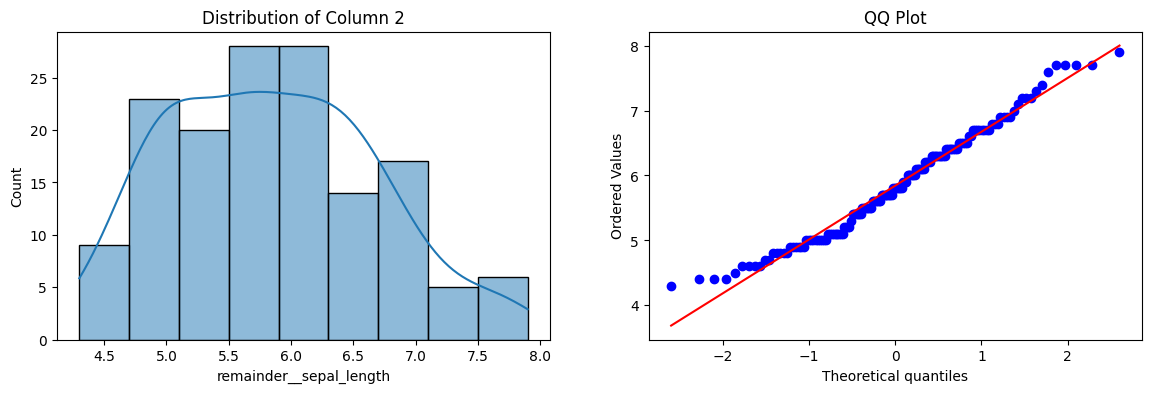

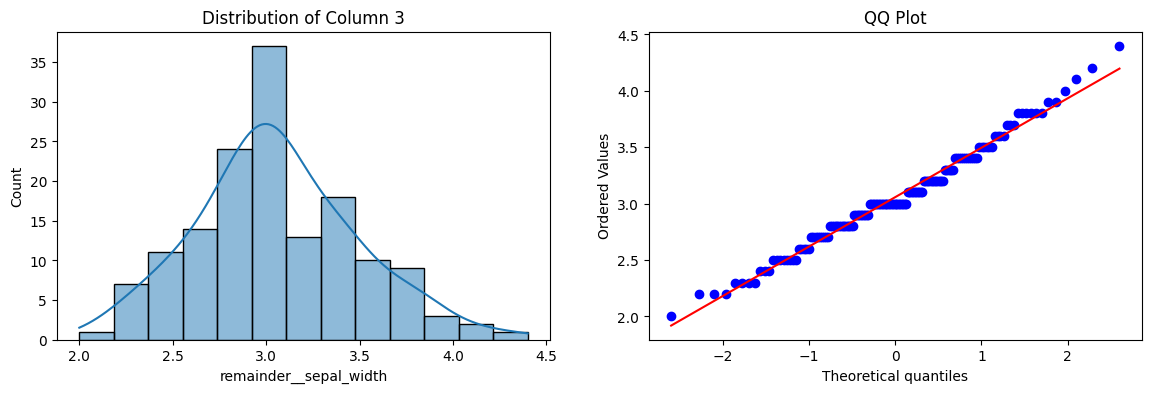

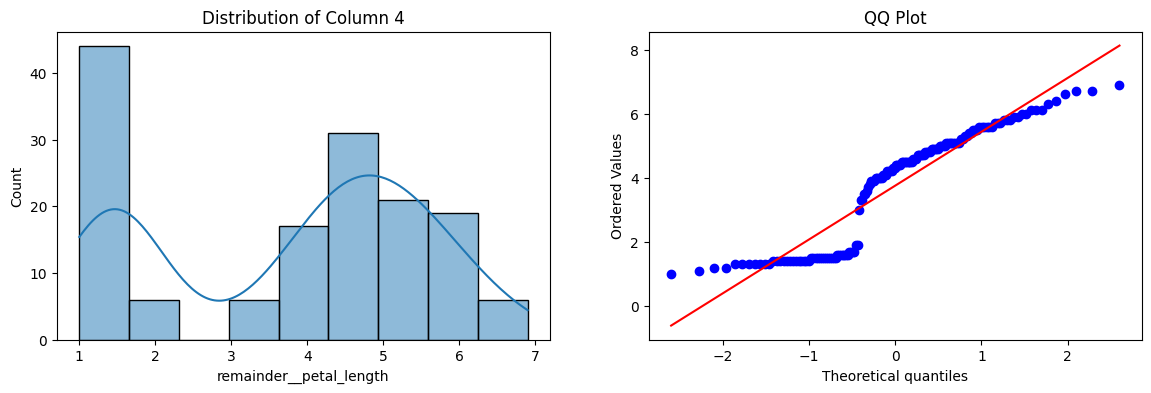

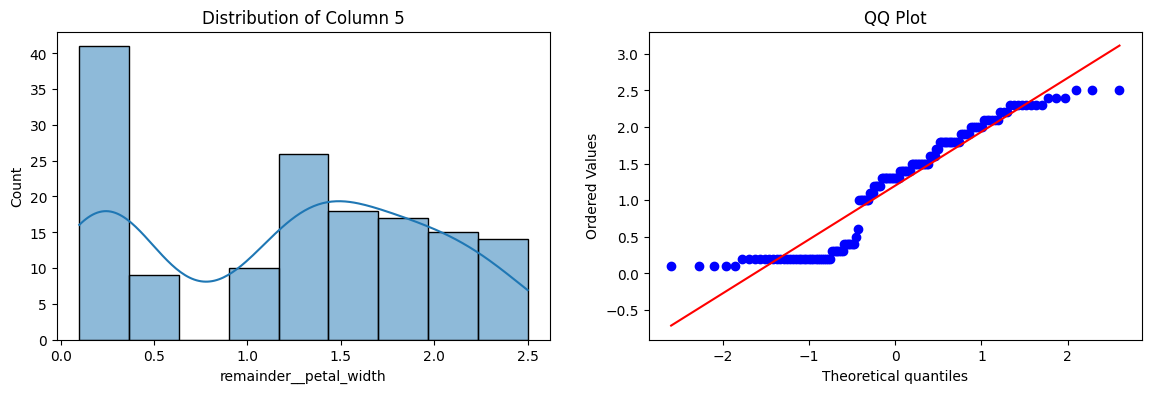

In [95]:
for i in range(2, 6):

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    sns.histplot(d1_df.iloc[:, i], kde=True)
    plt.title(f'Distribution of Column {i}')

    plt.subplot(122)
    stats.probplot(d1_df.iloc[:, i], dist="norm", plot=plt)
    plt.title('QQ Plot')

    plt.show()


In [ ]:
#we need to apply functon tranformation on petal_lenghth  and sepatl width

In [96]:
trf = FunctionTransformer(func=np.log1p)

In [98]:

d1_df['sepal_width_log1p'] = trf.fit_transform(df['sepal_width'].values.reshape(-1,1))
d1_df['petal_length_log1p'] = trf.fit_transform(df['petal_length'].values.reshape(-1,1))
d1_df['peatl_width_log1p'] = trf.fit_transform(df['petal_width'].values.reshape(-1,1))

In [99]:
df.head(2)

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_width_log1p,petal_length_log1p
0,5.1,3.5,1.4,0.2,setosa,1.504077,0.875469
1,4.9,3.0,1.4,0.2,setosa,1.386294,0.875469


In [100]:
d1_df.head(2)

,a__species_versicolor,a__species_virginica,remainder__sepal_length,remainder__sepal_width,remainder__petal_length,remainder__petal_width,sepal_width_log1p,petal_length_log1p,peatl_width_log1p
0,0.0,0.0,5.1,3.5,1.4,0.2,1.504077,0.875469,0.182322
1,0.0,0.0,4.9,3.0,1.4,0.2,1.386294,0.875469,0.182322


In [101]:
print(d1_df.columns)
d2_df = d1_df.drop(['remainder__sepal_width',
         'remainder__petal_length',
         'remainder__petal_width'], axis=1)

Index(['a__species_versicolor', 'a__species_virginica',
       'remainder__sepal_length', 'remainder__sepal_width',
       'remainder__petal_length', 'remainder__petal_width',
       'sepal_width_log1p', 'petal_length_log1p', 'peatl_width_log1p'],
      dtype='object')


In [102]:
d2_df.head(2)

,a__species_versicolor,a__species_virginica,remainder__sepal_length,sepal_width_log1p,petal_length_log1p,peatl_width_log1p
0,0.0,0.0,5.1,1.504077,0.875469,0.182322
1,0.0,0.0,4.9,1.386294,0.875469,0.182322


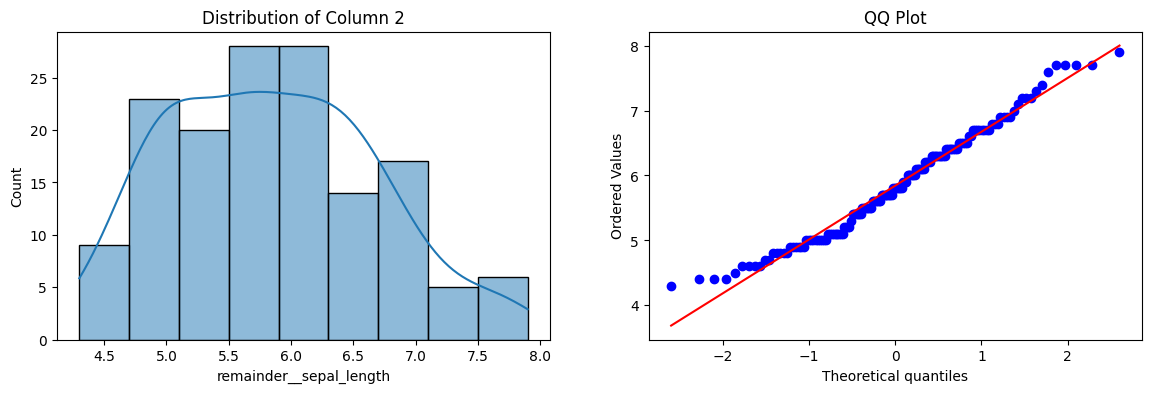

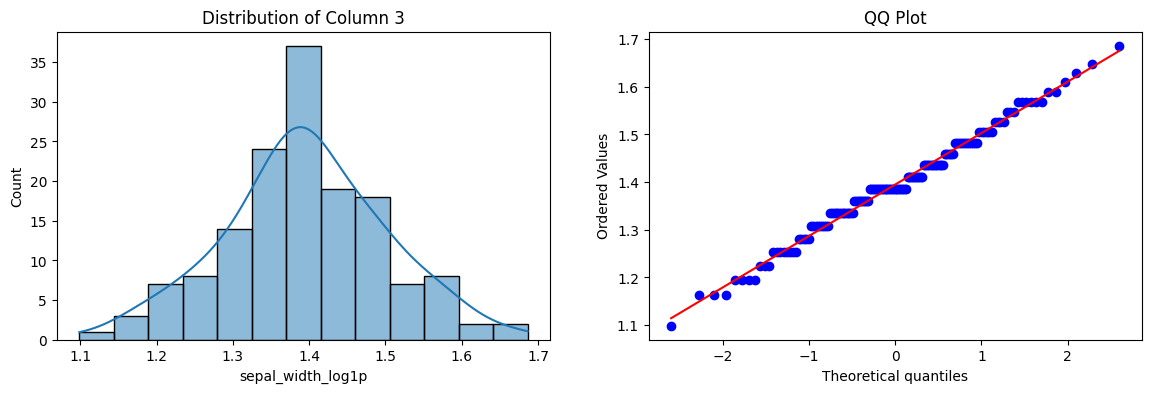

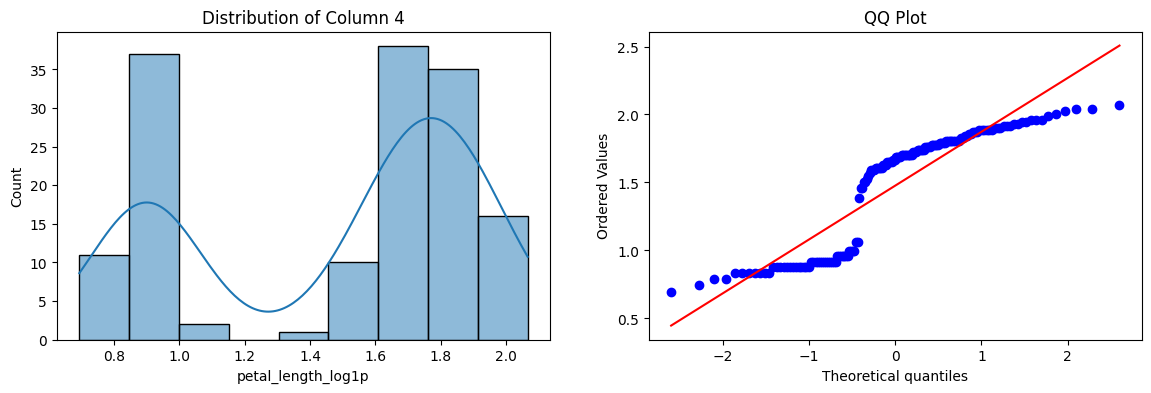

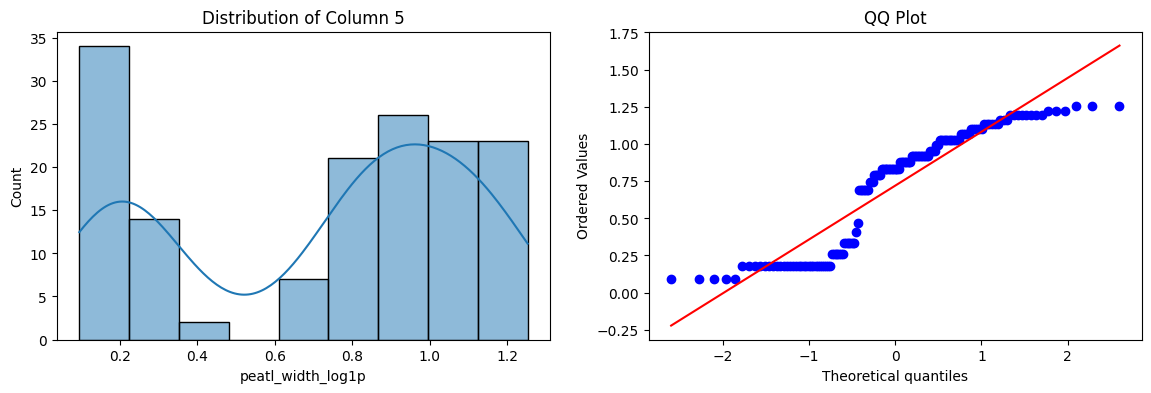

In [103]:
for i in range(2, 6):

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    sns.histplot(d2_df.iloc[:, i], kde=True)
    plt.title(f'Distribution of Column {i}')

    plt.subplot(122)
    stats.probplot(d2_df.iloc[:, i], dist="norm", plot=plt)
    plt.title('QQ Plot')

    plt.show()


In [104]:
trf = FunctionTransformer(func=np.sin)

In [105]:
d1_df['sepal_width_log1p'] = trf.fit_transform(df['sepal_width'].values.reshape(-1,1))
d1_df['petal_length_log1p'] = trf.fit_transform(df['petal_length'].values.reshape(-1,1))
d1_df['peatl_width_log1p'] = trf.fit_transform(df['petal_width'].values.reshape(-1,1))

In [107]:
d2_df = d1_df.drop(['remainder__sepal_width',
         'remainder__petal_length',
         'remainder__petal_width'], axis=1)

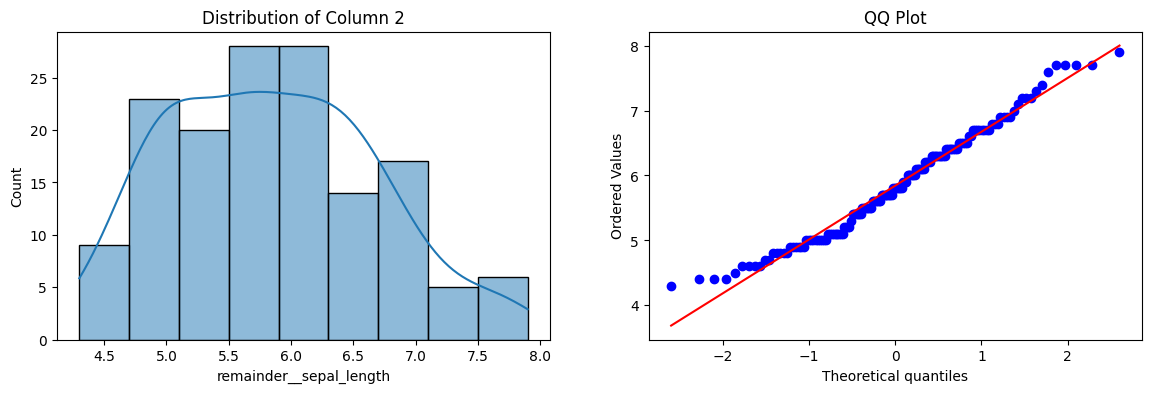

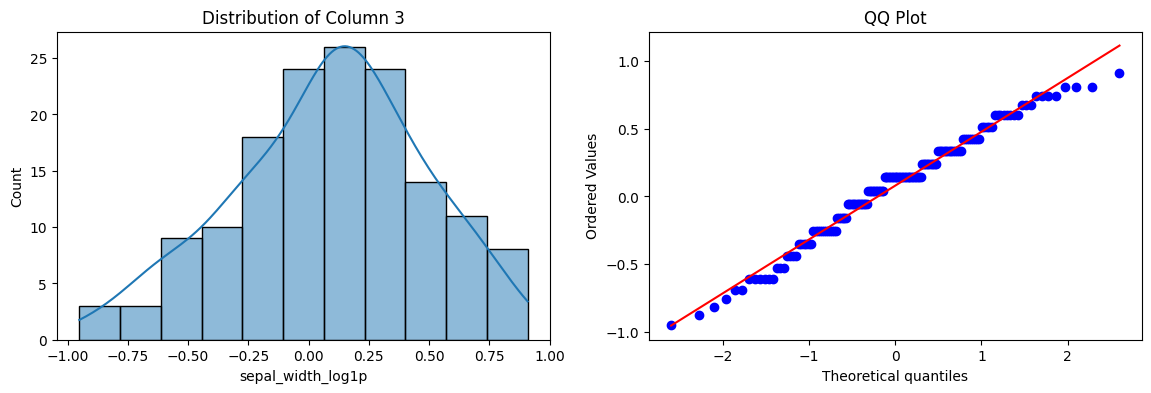

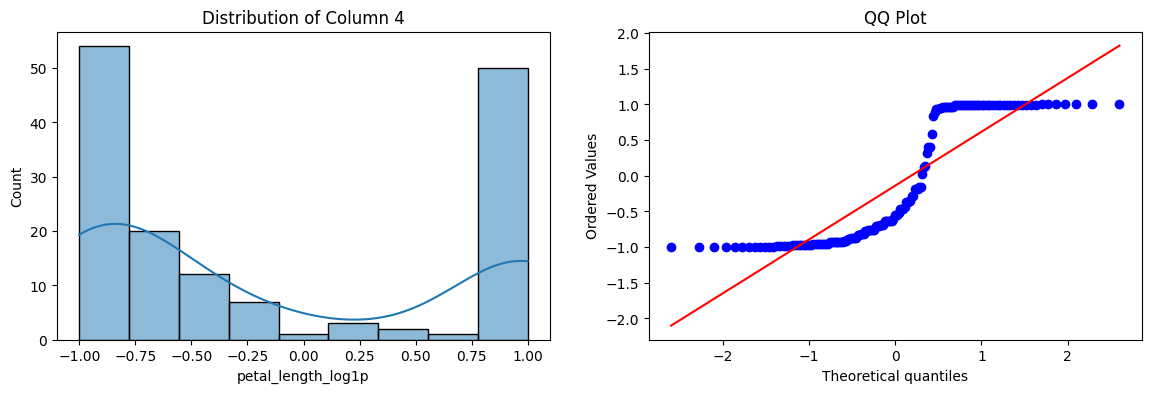

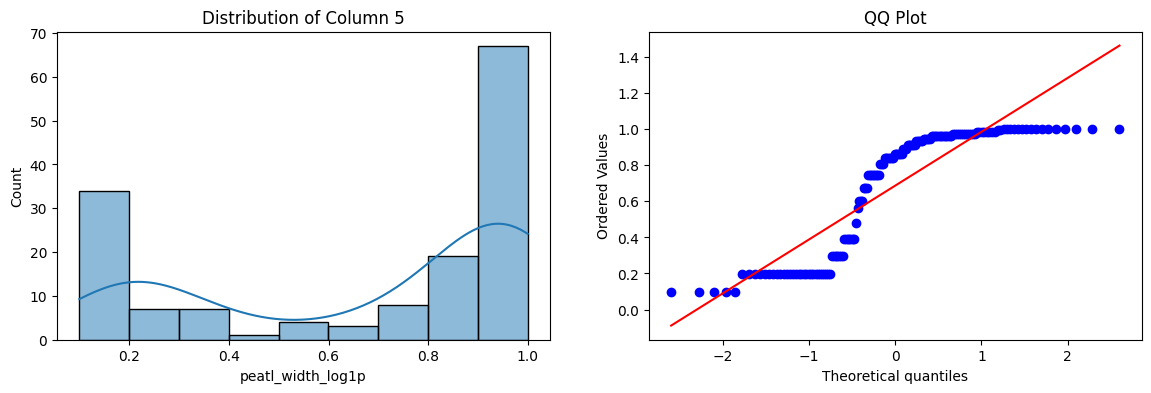

In [108]:
for i in range(2, 6):

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    sns.histplot(d2_df.iloc[:, i], kde=True)
    plt.title(f'Distribution of Column {i}')

    plt.subplot(122)
    stats.probplot(d2_df.iloc[:, i], dist="norm", plot=plt)
    plt.title('QQ Plot')

    plt.show()
